In [2]:
import torch    
import torch_geometric.transforms as T
import mdtraj as md
import os
import torch 
import numpy as np
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data, Dataset
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import BatchNorm1d
from torch_geometric.nn import GATConv, global_mean_pool, GCNConv, knn_graph, Linear
from torch.optim import SGD, Adam, Optimizer
import math
from torch.nn.init import kaiming_uniform_
from torch_geometric.transforms import ToDevice
import scipy
import sys
# from e3nn.io import CartesianTensor
# from torch_geometric.loader import DataLoader

device='cpu'
import torch
torch.cuda.is_available()

# print(torch.version.cuda)



True

In [ ]:
for i in [5,6,7,8,10]:
    pos_embedding_arr += torch.load("/data/pompei/bw973/Oxygenases/PHD2/PHD2-O2/Bundle/Sim%d/pos_embedding_inWater.pt"%i)
    print("+ Sim%d"%i,len(pos_embedding_arr), flush=True)

In [168]:
device='cuda'
pos_embedding_arr = []
neg_embedding_arr = []

for i in [1,2,5,7]:
    print(i)
    pos_embedding_arr += torch.load("/data/pompei/bw973/Oxygenases/PHD2/PHD2-O2/Bundle/Sim%d/posLowPeturb_embedding_inWater.pt"%i)
    print("+ Sim%d"%i,len(pos_embedding_arr))
    pos_embedding_arr += torch.load("/data/pompei/bw973/Oxygenases/PHD2/PHD2-O2/Bundle/Sim%d/pos_embedding_inWater.pt"%i)
    print("+ Sim%d"%i,len(pos_embedding_arr))
for i in [1,2,5,7]:
    print(i)
    neg_embedding_arr += torch.load("/data/pompei/bw973/Oxygenases/PHD2/PHD2-O2/Bundle/Sim%d/neg_embedding_inWater.pt"%i)
    print("- Sim%d"%i,len(neg_embedding_arr))

1
+ Sim1 7092
+ Sim1 8865
2
+ Sim2 23089
+ Sim2 26645
5
+ Sim5 28177
+ Sim5 28560
7
+ Sim7 31620
+ Sim7 32385
1
- Sim1 6676
2
- Sim2 19530
5
- Sim5 20991
7
- Sim7 23852


In [169]:

ps = [min(torch.norm(i.pos,dim=1)).item() for i in pos_embedding_arr]
ns = [min(torch.norm(i.pos,dim=1)).item() for i in neg_embedding_arr]

In [167]:
min(ns)

2.250000476837158

In [23]:
torch.norm(torch.tensor([-4.5, -0.5, -9.25])-torch.tensor([-7.322000, -0.644000, -8.329000]))

tensor(2.9720)

In [ ]:
min(ps)

2.0005178451538086

In [148]:
torch.norm(neg_embedding_arr[1091].pos,dim=1)

tensor([5.5644, 5.1043, 5.5168, 5.2299, 3.9954, 3.2539, 4.0392, 5.1154, 3.8284,
        2.9522, 4.1003, 5.2158, 5.8904, 5.5852, 5.5492, 5.0173, 3.8920, 3.0491,
        5.2053, 5.9656, 5.8654, 5.2661, 5.7941, 5.9333, 5.8116, 4.9226, 4.5950,
        5.0845, 5.5856, 5.9345, 5.0801, 4.8896, 5.5998, 4.0815, 5.4672, 4.7155,
        5.6739, 5.0546, 5.4448, 4.1167, 3.9490, 4.5446, 3.1876, 5.3303, 5.1158,
        5.7688, 5.9704, 5.0150, 4.5475, 5.4698, 5.8149, 4.1162, 3.9145, 3.3863,
        2.5825, 3.3153, 4.7515, 5.0155, 4.9821, 4.3227, 5.3362, 3.7320, 3.2093,
        4.5416, 5.3896, 5.2979, 5.8687, 4.6896, 4.1820, 3.4866, 5.1942, 5.8130,
        5.7403, 5.2712, 5.0316, 4.8310, 5.8188, 3.8965, 4.5395, 3.3939, 3.2046,
        5.5312, 5.9608, 4.8512, 3.1527, 2.9284, 2.7620, 3.6038, 3.5056, 4.5609,
        4.5456, 3.9097, 4.7679, 3.8570, 4.3497, 4.2844])

In [146]:
neg_embedding_arr[1090:1095]

[Data(x=[93, 25], pos=[93, 3], name='frame_10454_gas_613_sequence_218_path_P_main_in_1_neg', edge_index=[2, 8556], edge_attr=[8556, 1], center=[3], perturbed_from=[3], node_attr=[93, 3], node_directions=[93, 3], node_distances=[93], inside_indices=[93], local_inside_indices=[93], distance=[93]),
 Data(x=[96, 25], pos=[96, 3], name='frame_10454_gas_613_sequence_218_path_P_main_in_1_neg', edge_index=[2, 9120], edge_attr=[9120, 1], center=[3], perturbed_from=[3], node_attr=[96, 3], node_directions=[96, 3], node_distances=[96], inside_indices=[96], local_inside_indices=[96], distance=[96]),
 Data(x=[96, 25], pos=[96, 3], name='frame_10454_gas_613_sequence_218_path_P_main_in_1_neg', edge_index=[2, 9120], edge_attr=[9120, 1], center=[3], perturbed_from=[3], node_attr=[96, 3], node_directions=[96, 3], node_distances=[96], inside_indices=[96], local_inside_indices=[96], distance=[96]),
 Data(x=[96, 25], pos=[96, 3], name='frame_10454_gas_613_sequence_218_path_P_main_in_1_neg', edge_index=[2, 9

<AxesSubplot:ylabel='Density'>

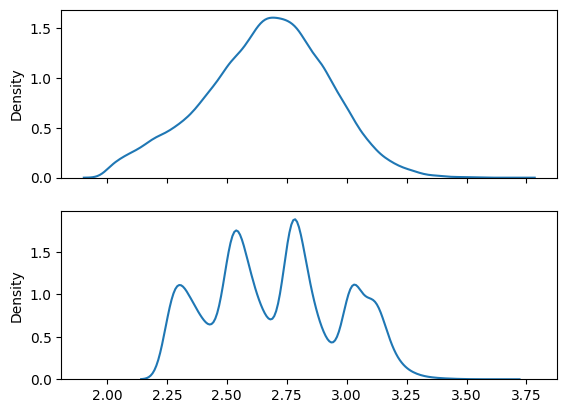

In [170]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2,1,sharex=True)
sns.kdeplot(ps, ax=ax[0])
sns.kdeplot(ns, ax=ax[1])

<AxesSubplot:ylabel='Density'>

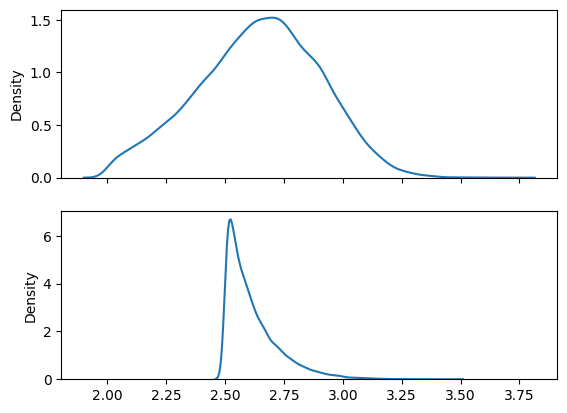

In [117]:
fig, ax = plt.subplots(2,1,sharex=True)
sns.kdeplot(ps, ax=ax[0])
sns.kdeplot(ns, ax=ax[1])

In [102]:
min(torch.norm(neg_embedding_arr[0].pos,dim=1))

tensor(2.5753)

In [ ]:
class PointCloudDataset(Dataset):
    def __init__(self, positives, negatives):
        self.positives = positives
        self.negatives = negatives
        # self.n = min(len(positives), len(negatives))
        # self.total = 2 * self.n
        self.n_pos = len(positives)
        self.n_neg = 2 * self.n_pos  # we expect negatives to be at least 2× positives
        
        # dataset size = pos + neg
        self.total = self.n_pos + self.n_neg

    def __len__(self):
        return self.total

    def __getitem__(self, idx):

        if idx < self.n_pos:
            return self.positives[idx], 1.0
        else:
            neg_idx = idx - self.n_pos
            return self.negatives[neg_idx], 0.0

In [68]:
full_dataset = PointCloudDataset(pos_embedding_arr[0:4000], neg_embedding_arr[0:15000])

val_loader = DataLoader(full_dataset, batch_size=32, shuffle=False)

In [10]:
from e3nn.io import CartesianTensor
from torch_geometric.loader import DataLoader
from copy import deepcopy
from e3nn import o3
from e3nn.o3 import FullyConnectedTensorProduct
from e3nn.nn import Gate
from e3nn.o3 import Irreps
from e3nn.nn.models.v2106.gate_points_networks import SimpleNetwork, NetworkForAGraphWithAttributes

model2=torch.load("/data/pompei/bw973/Oxygenases/PHD2/PHD2_O2QD/Bundle/Sim5/model7_FE2dis_inrWater4.pt")
model2 = model2.to('cuda')

In [70]:
epoch = 0
pos = []
neg = []
alls = []

with torch.no_grad():
    model2.eval()
    total_train = 0
    correct_train = 0
    pos_total_train = 0
    pos_correct_train = 0

    neg_total_train = 0
    neg_correct_train = 0

    
    for batch_idx, (data_list, labels) in enumerate(val_loader):
        print("labels.sum()",labels.sum())
        # If batch_size > 1, data_list will be a list of Data objects
        # Batch them for PyG model input:
        if isinstance(data_list, list):
            from torch_geometric.data import Batch
            batch = Batch.from_data_list(data_list)
        else:
            batch = data_list  # if batch_size=1, it might already be a Data object

        batch = batch.to('cuda')
        labels = labels.to('cuda')

        num_pos = (labels == 1).sum()
        num_neg = (labels == 0).sum()
            
        distance = torch.norm(batch.node_attr[:, :3], dim=1, keepdim=True)  # [N, 1]

        # 2. Convert Cartesian vectors to irreps vector
        x = CartesianTensor("i")
        vector_irrep = x.from_cartesian(batch.node_attr[:, :3])  # [N, 3]

        # 3. Concatenate scalar + vector as node_attr tensor
        atom_type_onehot = batch.x[:, 0:9]
        frame_emb = batch.x[:, 9:] 
        # node_attr = torch.cat([distance, vector_irrep, frame_emb], dim=1)
        node_attr = torch.cat([
            distance,            # 1 scalar (0e)
            # atom_type_onehot,    # 6 scalars (0e)
            frame_emb,           # k scalars (0e)
            vector_irrep,        # 3-vector (1o)
        ], dim=1)
        # node_input = torch.ones((batch.num_nodes, 1), device=batch.x.device)
        # node_input = torch.cat([
        #     # batch.distance.unsqueeze(-1), # 1 scalar (0e) distance of center of graph to iron
        #     batch.node_distances.unsqueeze(-1),    # 1 scalar (0e) distance to iron for each atom
        #     F.normalize(batch.node_directions, p=2, dim=1),        # 3-vector (1o) direction to iron for each atom
        # ], dim=1)

        data = {
            "batch": batch.batch,
            # "x": batch.x[:,0:6], # atom type
            # "frame_emb": frame,
            "x": atom_type_onehot,
            "node_attr": node_attr, 
            "edge_index": batch.edge_index,
            "edge_attr": batch.edge_attr,
            "pos": batch.pos,  # if needed in preprocess
        }
        
        # outputs = model(node_input, node_attr, edge_index, edge_attr).squeeze()
        outputs = model2(data)

        outs = torch.sigmoid(outputs.squeeze(-1))
        preds = (torch.sigmoid(outputs.squeeze(-1)) > 0.5)

        # Convert labels to bool
        labels_bool = labels.bool()

        # ---- metrics ----
        correct_train += (preds == labels_bool).sum().item()
        total_train += labels.size(0)

        # positive (label=1)
        pos += outs.cpu()[labels_bool.cpu()]
        neg += outs.cpu()[~labels_bool.cpu()]
        alls += preds
        
        pos_mask = labels_bool
        pos_total_train += pos_mask.sum().item()
        # pos_correct = ((preds & pos_mask)).sum().item()
        pos_correct_train += ((preds & pos_mask)).sum().item()
        if num_pos > 0:
            pos_acc = pos_correct_train / pos_total_train
        else:
            pos_acc = float("nan")

        # negative (label=0)
        neg_mask = ~labels_bool
        neg_total_train += neg_mask.sum().item()
        neg_correct_train += ((~preds & neg_mask)).sum().item()
        if neg_total_train > 0:
            neg_acc = neg_correct_train / neg_total_train
        else:
            neg_acc = float("nan")

        # print every 20 batches
        if (batch_idx + 1) % 20 == 0:
            train_acc = correct_train / total_train
            print(
                f"Epoch {epoch+1}, Batch {batch_idx+1} | "
                f"Val Acc: {train_acc:.4f} | "
                f"Val PosAcc: {pos_acc:.4f} | "
                f"Val NegAcc: {neg_acc:.4f}",
                flush=True
            )
        torch.cuda.empty_cache()
    train_accuracy = correct_train / total_train
    pos_acc_val = pos_correct_train / pos_total_train if pos_total_train > 0 else 0
    neg_acc_val = neg_correct_train / neg_total_train if neg_total_train > 0 else 0
    # torch.save(model2, "../Sim5/model%d_FE2dis_inrWater4.pt"%epoch)
    print('\tval_accuracy:', train_accuracy, flush=True)
    print('\tpos val_accuracy:', pos_acc_val, flush=True)
    print('\tneg val_accuracy:', neg_acc_val, flush=True)

labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
Epoch 1, Batch 20 | Val Acc: 0.8781 | Val PosAcc: 0.8781 | Val NegAcc: nan
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)


In [15]:
import seaborn as sns

In [71]:
pos2 = [p.item() for p in pos]
neg2 = [p.item() for p in neg]
alls2 = [p.item() for p in alls]

In [43]:
outs.cpu()

tensor([0.9540, 0.9673, 0.7056, 0.9827, 0.8653, 0.9533, 0.9703, 0.8645, 0.9253,
        0.9452, 0.8746, 0.9821, 0.9740, 0.9839, 0.9227, 0.9718, 0.9649, 0.9852,
        0.8484, 0.9451, 0.8277, 0.9673, 0.9595, 0.9724, 0.9765, 0.8460, 0.9811,
        0.9696, 0.9069, 0.9818, 0.9875, 0.8740])

<AxesSubplot:ylabel='Density'>

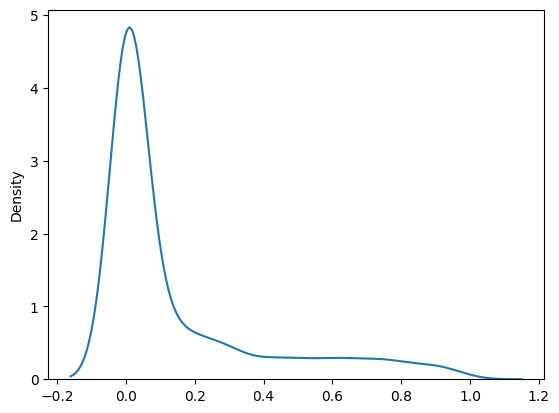

In [51]:
sns.kdeplot(neg2)

<AxesSubplot:ylabel='Density'>

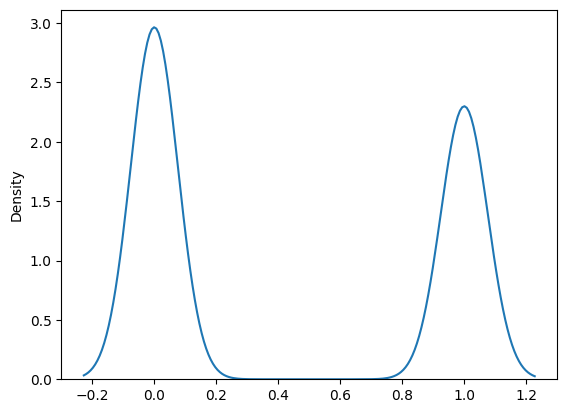

In [72]:
sns.kdeplot(alls2)

In [55]:

device='cuda'
pos_embedding_arr = []
neg_embedding_arr = []

for i in [1,9]:
    print(i)
    pos_embedding_arr += torch.load("/data/pompei/bw973/Oxygenases/PHD2/PHD2-O2/Bundle/Sim%d/pos_embedding_in4.pt"%i)
    print("+ Sim%d"%i,len(pos_embedding_arr))
for i in [1,9]:
    print(i)
    neg_embedding_arr += torch.load("/data/pompei/bw973/Oxygenases/PHD2/PHD2-O2/Bundle/Sim%d/neg_embedding_in4.pt"%i)
    print("- Sim%d"%i,len(neg_embedding_arr))

1
+ Sim1 1771
9
+ Sim9 7321
1
- Sim1 17730
9
- Sim9 73530


In [63]:
full_dataset = PointCloudDataset(pos_embedding_arr[0:4000], neg_embedding_arr[0:15000])

val_loader = DataLoader(full_dataset, batch_size=32, shuffle=False)

In [59]:
model2=torch.load("/data/pompei/bw973/Oxygenases/PHD2/PHD2_O2QD/Bundle/Sim5/model5_FE2dis_inrTESTING9.pt")
model2 = model2.to('cuda')

In [64]:
epoch = 0
pos_noH20 = []
neg_noH20 = []
alls_noH20 = []

with torch.no_grad():
    model2.eval()
    total_train = 0
    correct_train = 0
    pos_total_train = 0
    pos_correct_train = 0

    neg_total_train = 0
    neg_correct_train = 0

    
    for batch_idx, (data_list, labels) in enumerate(val_loader):
        print("labels.sum()",labels.sum())
        # If batch_size > 1, data_list will be a list of Data objects
        # Batch them for PyG model input:
        if isinstance(data_list, list):
            from torch_geometric.data import Batch
            batch = Batch.from_data_list(data_list)
        else:
            batch = data_list  # if batch_size=1, it might already be a Data object

        batch = batch.to('cuda')
        labels = labels.to('cuda')

        num_pos = (labels == 1).sum()
        num_neg = (labels == 0).sum()
            
        distance = torch.norm(batch.node_attr[:, :3], dim=1, keepdim=True)  # [N, 1]

        # 2. Convert Cartesian vectors to irreps vector
        x = CartesianTensor("i")
        vector_irrep = x.from_cartesian(batch.node_attr[:, :3])  # [N, 3]

        # 3. Concatenate scalar + vector as node_attr tensor
        atom_type_onehot = batch.x[:, 0:6]
        frame_emb = batch.x[:, 6:] 
        # node_attr = torch.cat([distance, vector_irrep, frame_emb], dim=1)
        node_attr = torch.cat([
            distance,            # 1 scalar (0e)
            # atom_type_onehot,    # 6 scalars (0e)
            frame_emb,           # k scalars (0e)
            vector_irrep,        # 3-vector (1o)
        ], dim=1)
        # node_input = torch.ones((batch.num_nodes, 1), device=batch.x.device)
        # node_input = torch.cat([
        #     # batch.distance.unsqueeze(-1), # 1 scalar (0e) distance of center of graph to iron
        #     batch.node_distances.unsqueeze(-1),    # 1 scalar (0e) distance to iron for each atom
        #     F.normalize(batch.node_directions, p=2, dim=1),        # 3-vector (1o) direction to iron for each atom
        # ], dim=1)

        data = {
            "batch": batch.batch,
            # "x": batch.x[:,0:6], # atom type
            # "frame_emb": frame,
            "x": atom_type_onehot,
            "node_attr": node_attr, 
            "edge_index": batch.edge_index,
            "edge_attr": batch.edge_attr,
            "pos": batch.pos,  # if needed in preprocess
        }
        
        # outputs = model(node_input, node_attr, edge_index, edge_attr).squeeze()
        outputs = model2(data)

        outs = torch.sigmoid(outputs.squeeze(-1))
        preds = (torch.sigmoid(outputs.squeeze(-1)) > 0.5)

        # Convert labels to bool
        labels_bool = labels.bool()

        # ---- metrics ----
        correct_train += (preds == labels_bool).sum().item()
        total_train += labels.size(0)

        # positive (label=1)
        pos_noH20 += outs.cpu()[labels_bool.cpu()]
        neg_noH20 += outs.cpu()[~labels_bool.cpu()]
        alls_noH20 += preds
        
        pos_mask = labels_bool
        pos_total_train += pos_mask.sum().item()
        # pos_correct = ((preds & pos_mask)).sum().item()
        pos_correct_train += ((preds & pos_mask)).sum().item()
        if num_pos > 0:
            pos_acc = pos_correct_train / pos_total_train
        else:
            pos_acc = float("nan")

        # negative (label=0)
        neg_mask = ~labels_bool
        neg_total_train += neg_mask.sum().item()
        neg_correct_train += ((~preds & neg_mask)).sum().item()
        if neg_total_train > 0:
            neg_acc = neg_correct_train / neg_total_train
        else:
            neg_acc = float("nan")

        # print every 20 batches
        if (batch_idx + 1) % 20 == 0:
            train_acc = correct_train / total_train
            print(
                f"Epoch {epoch+1}, Batch {batch_idx+1} | "
                f"Val Acc: {train_acc:.4f} | "
                f"Val PosAcc: {pos_acc:.4f} | "
                f"Val NegAcc: {neg_acc:.4f}",
                flush=True
            )
        torch.cuda.empty_cache()
    train_accuracy = correct_train / total_train
    pos_acc_val = pos_correct_train / pos_total_train if pos_total_train > 0 else 0
    neg_acc_val = neg_correct_train / neg_total_train if neg_total_train > 0 else 0
    # torch.save(model2, "../Sim5/model%d_FE2dis_inrWater4.pt"%epoch)
    print('\tval_accuracy:', train_accuracy, flush=True)
    print('\tpos val_accuracy:', pos_acc_val, flush=True)
    print('\tneg val_accuracy:', neg_acc_val, flush=True)

labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
Epoch 1, Batch 20 | Val Acc: 0.8469 | Val PosAcc: 0.8469 | Val NegAcc: nan
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)
labels.sum() tensor(32.)


In [65]:
pos2_noH20 = [p.item() for p in pos_noH20]
neg2_noH20 = [p.item() for p in neg_noH20]
alls2_noH20 = [p.item() for p in alls_noH20]

<AxesSubplot:ylabel='Density'>

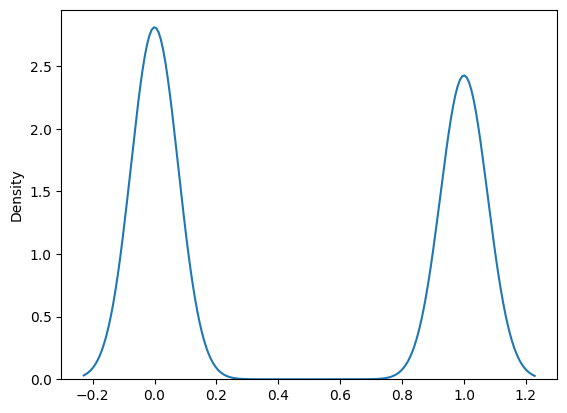

In [66]:
sns.kdeplot(alls2_noH20)

In [5]:
import MDAnalysis as mda

top ='../Sim9/equil5.gro'
Sim=9 # not 2,3,7
t = "../Sim%d/fit2_small.dcd"%Sim
u = mda.Universe(top, t)

In [6]:
# from rdkit import Chem
# mol = Chem.MolFromPDBFile("an1.pdb", removeHs=False)
# Chem.SanitizeMol(mol)
from rdkit import Chem
mol = Chem.MolFromPDBFile("../Sim9/an1_water.pdb", removeHs=False)
Chem.SanitizeMol(mol)

# top ='../Sim9/equil5.gro'
# Sim=9 # not 2,3,7
# t = "../Sim%d/frame_32041_allAtoms_translated.pdb"%Sim
# traj = md.load(t, top=top)

# xyz = torch.tensor(traj.xyz) * 10
# ele2num = {"C": 0, "H": 1, "O": 2, "N": 3, "S": 4, "VS": {"FE": 5, "MG":6}} # all 0's will be padding for gases not within 3.5 angstroms of any protein atom
ele2num = {"C": 0, "H": 1, "O": 2, "N": 3, "S": 4, "Fe": 5, "Mg":6, "Na":7, "Cl":8}
t = "../Sim%d/an1_water.pdb"%Sim
traj = md.load_frame(t, index=0,top=top)
gas='O2IF'
metal='FE'
gas2 = traj.topology.select('resname %s' % gas)
residue_ref = np.array([traj.topology.atom(ind).residue.resSeq for ind in gas2])
FE = traj.topology.select('resname Fe2p')
residue_sel_un = np.unique(residue_ref) # gas
residue_sel_un

print('LEN FE', FE)
residue_sel_un = np.unique(residue_ref) # gas
residue_sel_un
nogas = np.setdiff1d(range(0,traj.xyz.shape[1]),gas2)
rnames = np.array([traj.topology.atom(ind).residue.name for ind in nogas])
rindex = np.array([traj.topology.atom(ind).residue.resSeq for ind in nogas])
anames = np.array([traj.topology.atom(ind).element.symbol for ind in nogas])
anames2=np.array([traj.topology.atom(i).name for i in nogas])
anums = [ele2num[a] if a != 'VS' else ele2num[a][metal] for a in anames]

# rnames = np.array([traj.topology.atom(ind).residue.name for ind in nogas])
# rindex = np.array([traj.topology.atom(ind).residue.resSeq for ind in nogas])
# anames = np.array([traj.topology.atom(ind).element.symbol for ind in nogas])
rnames2 = np.array([traj.topology.atom(ind).residue for ind in nogas])

cat = np.where(anames=='Fe')[0]
print(cat)

device = torch.device("cpu")
# device = torch.device("cpu")
# protein_coords_traj = xyz[:,nogas,:]
rs = int(len(residue_ref)/len(residue_sel_un))
gas_atoms=gas2.reshape(len(residue_sel_un),2)

# dioxygen_coords_ave = xyz[:,gas2,:].reshape(-1,len(residue_sel_un),rs,3).mean(axis=2)
# d=torch.cdist(dioxygen_coords_ave, xyz[:,cat,:])
# diox = np.where(d < 6.0)[1]
# frames = np.where(d < 6.0)[0]

types_array_atom = torch.zeros((len(nogas)+len(gas2), (len(ele2num))))
for i, t in enumerate(anums):
    types_array_atom[i,t] = 1.0
# types_array_atom.shape
types_array_atom[-len(gas2):,ele2num['O']] = 1
types_array_atom = types_array_atom.to(device)

gas_idx = np.where(residue_sel_un==10000)[0]
gas_idx
# protein_cofactors = torch.tensor(nogas).to(device)
# global_to_local = {int(g): i for i, g in enumerate(np.arange(0,xyz[:,nogas,:].shape[1]))}
protein_cofactors = torch.tensor(np.setdiff1d(np.arange(0,len(u.atoms)), gas_atoms[gas_idx])).to(device)
global_to_local = {int(g): i for i, g in enumerate(protein_cofactors)}

del traj

t = "../Sim%d/an1_water.pdb"%Sim
traj = md.load_frame(t, index=0,top=top)

/home/bw973/.conda/envs/holoprot/lib/python3.10/site-packages/mdtraj/formats/pdb/pdbstructure.py:579: UserWarning: WARNING: two consecutive residues with same number (ATOM      7  N   GLN A 184      19.741  63.070  54.031  1.00  0.00           N  , ATOM      6  O   ACE A 184      17.771  62.964  52.900  1.00  0.00           O  )
  warnings.warn(
/home/bw973/.conda/envs/holoprot/lib/python3.10/site-packages/mdtraj/formats/pdb/pdbstructure.py:579: UserWarning: WARNING: two consecutive residues with same number (ATOM   3506  N   ASP B 558      51.654  33.652  33.228  1.00  0.00           N  , ATOM   3505  O   ACE B 558      49.858  33.843  31.862  1.00  0.00           O  )
  warnings.warn(


LEN FE [3790]
[3790]


In [7]:
residue_sel_un[10]

587

In [ ]:
close = traj.topology.select('resname VAL and residue 314 and name O')
close
d2=torch.cdist(dioxygen_coords_ave, xyz[:,close,:])

In [21]:
# Sim9
start=11110
# start=start=19901
step=1
actuals=[]
# frame_pos=torch.tensor([4.75, 12.5, 2.0])
# frame_pos=torch.tensor([-7.75, 4.5, 2.5])
for start in range(start+0,start+101):

    # print("START:", start)
    do_coords = dioxygen_coords_ave[start,26,:]
    protein_coords_traj = xyz[start,nogas,:]
    translated = do_coords - protein_coords_traj.cpu()[cat].numpy() 
    # print(start,":", translated)
    actuals.append(translated[0])




In [29]:
# Sim9
start=11068
# start=start=19901
step=1
actuals=[]
# frame_pos=torch.tensor([4.75, 12.5, 2.0])
# frame_pos=torch.tensor([-7.75, 4.5, 2.5])
for start in range(start+0,start+70):
    do_coords = dioxygen_coords_ave[start,32,:]
    protein_coords_traj = xyz[start,nogas,:]
    translated = do_coords - protein_coords_traj.cpu()[cat].numpy() 
    actuals.append(translated[0])

In [38]:
# Sim9
start=3926
end=83
# start=start=19901
step=1
actuals=[]
# frame_pos=torch.tensor([4.75, 12.5, 2.0])
# frame_pos=torch.tensor([-7.75, 4.5, 2.5])
for start in range(start+0,start+(end-1)):
    u.trajectory[start]
    coords = torch.tensor(u.atoms.positions.copy())
    dioxygen_coords_ave = coords[gas2].reshape(len(residue_sel_un),rs,3).mean(axis=1)
    do_coords = dioxygen_coords_ave[10]
    protein_coords_traj = coords[nogas]
    translated = do_coords - protein_coords_traj.cpu()[cat].numpy() 
    actuals.append(translated[0])
    step+=1
torch.norm(torch.stack(actuals),dim=1)

tensor([19.5878, 18.9069, 19.1250, 19.7511, 19.3909, 14.4728, 17.1779, 16.0174,
        16.1345, 15.7624, 12.5302, 10.0899, 10.0086,  9.6248, 10.7392,  9.4325,
         8.6590,  8.6512,  8.4509,  6.9854,  6.5022,  6.9601,  8.2295,  7.6185,
         7.5392,  6.0750,  6.7131,  9.4377,  9.3672,  9.5591,  8.8986,  6.6782,
         8.2745,  8.5405,  7.6316,  8.4010,  8.3167,  8.1485,  8.5151,  7.1106,
         8.5226,  7.4403,  8.6876,  8.6983,  8.5245,  8.3559,  9.6437,  8.8135,
         9.0499,  8.0827, 10.2639,  8.5551,  7.8201,  8.8044,  8.9635,  7.7213,
         7.6048,  9.3789,  7.8120,  7.6821,  8.0853,  8.1736,  6.9672,  8.1855,
         8.4294,  7.9719,  8.6963,  9.1744,  8.9003,  9.2291,  7.3617,  7.9047,
         8.6708,  8.1365,  7.8630,  8.1942,  8.1942,  8.0507,  7.9809,  8.1569,
         6.6302,  5.5226])

In [13]:
coords[gas2].shape

torch.Size([200, 3])

In [10]:
coords[gas2].reshape(len(residue_sel_un),rs,3).mean(axis=1).shape

torch.Size([100, 3])

In [14]:
# Sim5
start=10239
step=1
actuals=[]
# frame_pos=torch.tensor([4.75, 12.5, 2.0])
# frame_pos=torch.tensor([-7.75, 4.5, 2.5])
for start in range(start+0,start+268):

    # print("START:", start)
    do_coords = dioxygen_coords_ave[start,36,:]
    protein_coords_traj = xyz[start,nogas,:]
    translated = do_coords - protein_coords_traj.cpu()[cat].numpy() 
    # print(start,":", translated)
    actuals.append(translated[0])




In [42]:
import pandas as pd

# df = pd.read_csv("../Sim9/18_FE2dis_inrTESTING2_7.csv", header=None)
df = pd.read_csv("../Sim5/18_FE2dis_inrTESTING2_21.csv", header=None)

In [15]:
actuals

[tensor([ -9.8259,  -0.9034, -16.9209]),
 tensor([-10.5575,   0.5433, -15.6753]),
 tensor([-10.4491,   2.7436, -15.7815]),
 tensor([ -6.5343,   0.1935, -18.6379]),
 tensor([ -5.7911,   3.7700, -18.1178]),
 tensor([ -5.2282,   2.5309, -13.2560]),
 tensor([ -5.3503,   3.9696, -15.8334]),
 tensor([ -5.5251,   3.6505, -14.5844]),
 tensor([ -5.8077,   4.8924, -14.2358]),
 tensor([ -3.4247,   1.4198, -15.3202]),
 tensor([ -4.3519,   2.4502, -11.4919]),
 tensor([-2.9207,  0.4701, -9.6465]),
 tensor([-3.6978,  0.6037, -9.2809]),
 tensor([-3.7782,  0.8432, -8.8119]),
 tensor([-3.9529,  0.3104, -9.9805]),
 tensor([-4.0044,  0.5729, -8.5210]),
 tensor([-3.5224, -2.2116, -7.5948]),
 tensor([-5.7721, -0.8351, -6.3898]),
 tensor([-5.2150, -1.9003, -6.3726]),
 tensor([-4.4156,  0.4737, -5.3920]),
 tensor([-3.6615,  0.7004, -5.3274]),
 tensor([-4.2770, -0.4234, -5.4747]),
 tensor([-3.1636, -0.5245, -7.5790]),
 tensor([-3.7766, -1.6889, -6.3974]),
 tensor([-2.4792,  2.4544, -6.6835]),
 tensor([-3.5433,

In [24]:
torch.norm(torch.stack(actuals),dim=1)

tensor([14.4728, 17.1779, 16.0174, 16.1345, 15.7624, 12.5302, 10.0899, 10.0086,
         9.6248, 10.7392,  9.4325,  8.6590,  8.6512,  8.4509,  6.9854,  6.5022,
         6.9601,  8.2295,  7.6185,  7.5392,  6.0750,  6.7131,  9.4377,  9.3672,
         9.5591,  8.8986,  6.6782,  8.2745,  8.5405,  7.6316,  8.4010,  8.3167,
         8.1485,  8.5151,  7.1106,  8.5226,  7.4403,  8.6876,  8.6983,  8.5245,
         8.3559,  9.6437,  8.8135,  9.0499,  8.0827, 10.2639,  8.5551,  7.8201,
         8.8044,  8.9635,  7.7213,  7.6048,  9.3789,  7.8120,  7.6821,  8.0853,
         8.1736,  6.9672,  8.1855,  8.4294,  7.9719,  8.6963,  9.1744,  8.9003,
         9.2291,  7.3616,  7.9047,  8.6708,  8.1365,  7.8630,  8.1942,  8.1942,
         8.0507,  7.9809,  8.1569,  6.6302,  5.5226])

In [43]:
shape=torch.norm(torch.tensor(df.loc[:,1:3].values),dim=1).shape[0]
shape

82

In [ ]:
torch.norm(torch.tensor(df.loc[:,1:3].values[0:shape]) - torch.stack(actuals)[0:shape],dim=1).mean()

tensor(2.1076, dtype=torch.float64)

In [44]:
torch.norm(torch.tensor(df.loc[:,1:3].values[0:shape]) - torch.stack(actuals)[0:shape],dim=1).mean()

tensor(0.7884, dtype=torch.float64)

In [ ]:
torch.norm(torch.tensor(df.loc[:,1:3].values[0:257]) - torch.stack(actuals)[0:257],dim=1).mean() # .9sh # Sim 5 actual event 2.69 ns in time

tensor(3.2470, dtype=torch.float64)

In [12]:
torch.norm(torch.tensor(df.loc[:,1:3].values[0:257]) - torch.stack(actuals)[0:257],dim=1).mean() 

tensor(4.8827, dtype=torch.float64)

In [7]:
# types_array_atom.shape
def build_complete_edge_index(N, device):
    idx = torch.arange(N, device=device)
    i, j = torch.meshgrid(idx, idx, indexing="ij")

    mask = i != j  # no self-loops
    edge_index = torch.stack([i[mask], j[mask]], dim=0)
    return edge_index

# DO THIS ONCE
global_bonds = []  # (a1, a2, order)

for bond in mol.GetBonds():
    a1 = bond.GetBeginAtomIdx()
    a2 = bond.GetEndAtomIdx()

    if a1 in gas_atoms or a2 in gas_atoms:
        continue

    bt = bond.GetBondType()
    order = (
        1 if bt == Chem.rdchem.BondType.SINGLE else
        2 if bt == Chem.rdchem.BondType.DOUBLE else
        3 if bt == Chem.rdchem.BondType.AROMATIC else
        1
    )

    global_bonds.append((a1, a2, order))
    global_bonds.append((a2, a1, order))

# gas bonds
for a1, a2 in gas_atoms:
    global_bonds.append((a1, a2, 1))
    global_bonds.append((a2, a1, 1))


from torch_geometric.data import Data
def extract_point_cloud(atom_matrix, positions, center):
    """
    Formats the already-cropped atom features and positions into a Data object.
    """
    if positions.shape[0] == 0:
        return None  # Skip empty cubes

    # Center coordinates relative to cube center
    centered_positions = positions - center

    return Data(x=atom_matrix, pos=centered_positions)

path_dict = {
    'P1':'P1', 
    'P_main (PmR)':'PmR', 
    'P_main (mid)':'mid', 
    'P_reverse':'P_reverse', 
    'P_main (PmL)':'PmL',
       'P3':'P3'
}

def write_pdb2(inds, what, xs, ys, zs, chain='C', file="ml_out.pdb"):
    
    print(file)
    
    fpdb = open(file, 'wt')
    norm = torch.max(what[inds])
    i_atom = 1
    i_resid = 1
    for i, dind in enumerate(inds):

        fpdb.write('{:6s}{:5d} {:^4s}{:1s}{:3s} {:1s}{:4d}{:1s}   {:8.3f}{:8.3f}{:8.3f}{:6.2f}{:6.2f}          {:>2s}{:2s}\n'.format(
            'ATOM',i_atom,
            'GG','','GG',
            chain,i_resid,'',
            xs[dind],ys[dind],zs[dind],
            -1.0*torch.log10(what[dind]/norm),(what[dind]),
            'K',''))
        i_atom += 1
        if i_atom > 999:
            i_atom = 1
            i_resid += 1
            #eigv[dind,0],mm.pi[dind],
    fpdb.write('TER\n')
    fpdb.close()

def axis_without_center(minv, maxv, space, hole=3.5):
    left  = np.arange(minv, -hole, space)
    right = np.arange(hole, maxv + space, space)
    return np.concatenate([left, right])

import numpy as np
import torch


def get_points(
    start,
    translated,          # [N_atoms, 3]
    frame_pos,           # [3]
    space=0.65,
    bottom_threshold=2.5,
    top_threshold=3.5,
    min_radius=12.,
    max_radius=25.,
    distance_to=20.0,
    chunk_size=2048,
):
    """
    Generate grid points, exclude points too close to atoms,
    and keep points near frame_pos.

    Memory safe: no full distance matrix.
    """

    device = translated.device

    # ---------------------------------------------------------
    # 1. Grid extent selection
    # ---------------------------------------------------------
    if distance_to <= 7.5:
        extent = 11
    elif distance_to <= 9:
        extent = 13
    elif distance_to <= 12:
        extent = 16
    else:
        extent = 25

    edges = np.arange(-extent, extent + space, space)

    # ---------------------------------------------------------
    # 2. Generate spherical shell grid
    # ---------------------------------------------------------
    pts = []
    rmin2 = 3.5 ** 2
    rmax2 = extent ** 2

    for x in edges:
        x2 = x * x
        for y in edges:
            xy2 = x2 + y * y
            if xy2 > rmax2:
                continue
            for z in edges:
                r2 = xy2 + z * z
                if rmin2 <= r2 <= rmax2:
                    pts.append((x, y, z))

    points_3d = torch.tensor(pts, dtype=torch.float32, device=device)

    # ---------------------------------------------------------
    # 3. Cull atoms that can never affect kept points
    # ---------------------------------------------------------
    # Worst-case geometry bound
    print(torch.norm(frame_pos), max(max_radius, distance_to), top_threshold)
    max_relevant = torch.norm(frame_pos) + max(max_radius, distance_to) + top_threshold

    atom_dist = torch.norm(translated, dim=1)
    atom_mask = atom_dist <= max_relevant
    exclude_points = translated[atom_mask]

    # ---------------------------------------------------------
    # 4. Distance-based exclusion (chunked)
    # ---------------------------------------------------------
    min_dist = torch.full(
        (points_3d.shape[0],),
        float("inf"),
        device=device
    )

    for i in range(0, exclude_points.shape[0], chunk_size):
        ep = exclude_points[i:i + chunk_size]
        d = torch.cdist(points_3d, ep)           # [P, chunk]
        min_dist = torch.minimum(min_dist, d.min(dim=1).values)

    # outside bottom_threshold AND inside top_threshold
    valid = (min_dist >= bottom_threshold) & (min_dist < top_threshold)
    filtered_points = points_3d[valid]

    # ---------------------------------------------------------
    # 5. Final restriction around frame_pos
    # ---------------------------------------------------------
    dist_to_frame = torch.norm(filtered_points - frame_pos, dim=1)

    
    filtered_points = filtered_points[(dist_to_frame <= max_radius) & (dist_to_frame >= min_radius)]

    return filtered_points



def get_fe_bias(
    xyz2,
    frame_pos,
    point=None,
    alpha=10.0,
    beta=1.0,
    denom=4,
    range_=0.75,
):
    """
    alpha → dominance of reference-point distance
    beta  → influence of closeness to the line
    point → reference point [3], defaults to origin
    """

    if point is None:
        point = torch.zeros(3, device=xyz2.device, dtype=xyz2.dtype)
    else:
        point = torch.as_tensor(point, device=xyz2.device, dtype=xyz2.dtype)

    # Shift coordinates so "point" becomes the origin
    xyz_rel = xyz2 - point  # [N, 3]

    # ------------------------------
    # Distance to reference point (dominant term)
    # ------------------------------
    dist_point = torch.norm(xyz_rel, dim=1)  # [N]
    origin_score = 1.0 / (dist_point**denom + 1e-8)

    # ------------------------------
    # Distance to line through `point`
    # ------------------------------
    line_dir = frame_pos / torch.norm(frame_pos)  # [3]
    t = (xyz_rel * line_dir).sum(dim=1, keepdim=True)
    d_perp = torch.norm(xyz_rel - t * line_dir, dim=1)

    line_score = 1.0 / (d_perp + 1e-8)

    # ------------------------------
    # Combine WITHOUT global normalization
    # ------------------------------
    combined = alpha * origin_score + beta * line_score

    # ------------------------------
    # Scale result to 0–range_ while preserving ranking
    # ------------------------------
    combined_min = combined.min()
    combined_max = combined.max()

    score = range_ * (combined - combined_min) / (combined_max - combined_min + 1e-8)

    return score


import torch
def get_best(density, pos_embedding, k=5):
# points: [N,3], density: [N]
    # k = 5
    points = torch.stack([p.center for p in pos_embedding])
    # density=density
    N = points.shape[0]

    best_sum = -1
    best_group = None
    best_ndx = None
    scores = {}

    for i in range(N):
        # compute distances from point i
        dists = torch.norm(points - points[i], dim=1)  # [N]
        
        # find indices of the closest k points including self
        _, nn_idx = torch.topk(-dists, k)  # negative because topk returns largest
        
        # sum densities in this group
        group_density = density[nn_idx].sum()
        scores[i] = {}
        scores[i]['group_density'] = group_density
        scores[i]['nn_idx'] = nn_idx
        
        if group_density > best_sum:
            best_sum = group_density
            best_group = nn_idx
            best_ndx = i

    highest_cluster_points = points[best_group]
    highest_cluster_density = density[best_group]

    return scores, points


def topk_with_radius(density, pos_embedding, k=5, radius=2.0, threshold=0.5):
    density = density.to('cpu')
    points = torch.stack([p.center for p in pos_embedding])
    keep = torch.where(density > threshold)[0]
    while len(keep) < (3*k):
        print(len(keep),threshold)
        threshold = threshold/2
        if np.isclose(0,threshold,.001):
            break
        keep = torch.where(density > threshold)[0]
        print(len(keep),threshold)
    points = points[keep]
    density = density[keep]
    print("Keeping:", density.shape, ", at score >=", threshold)
    N = points.shape[0]
    best_sum = -1
    best_group = None
    best_ndx = None
    scores = {}

    for i in range(N):
        # distances from point i
        dists = torch.norm(points - points[i], dim=1)

        # initial K nearest indices (including itself)
        _, nn_idx = torch.topk(-dists, k)

        # extract positions of candidate group
        group_pts = points[nn_idx]            # [k,3]

        # compute pairwise distance matrix within group
        pdist = torch.norm(
            group_pts.unsqueeze(1) - group_pts.unsqueeze(0),
            dim=2
        )  # [k, k]
        # check radius requirement: all pairwise distances ≤ radius
        if (pdist <= radius).all():
            group_density = density[nn_idx].sum()

            if group_density > best_sum:
                best_sum = group_density
                best_group = nn_idx
                best_ndx = i
            scores[i] = {}
            scores[i]['group_density'] = group_density
            scores[i]['nn_idx'] = nn_idx

    return scores, points

# Map from global RDKit atom idx → local 0..N-1
import itertools

def build_edges_and_attrs_fast(inside_indices, edge_index_cache):
    device = inside_indices.device
    N = inside_indices.shape[0]

    # global → local
    atom_to_local = {int(a): i for i, a in enumerate(inside_indices.tolist())}

    # edge_index is reused
    edge_index = edge_index_cache

    # initialize all nonbonded = 0
    edge_attr = torch.zeros(
        (edge_index.shape[1], 1),
        dtype=torch.long,
        device=device
    )

    # overwrite bonded edges only
    # map (i,j) → edge position once
    edge_pos = {
        (int(i), int(j)): k
        for k, (i, j) in enumerate(edge_index.t().tolist())
    }

    for a1, a2, order in global_bonds:
        if a1 in atom_to_local and a2 in atom_to_local:
            i = atom_to_local[a1]
            j = atom_to_local[a2]
            edge_attr[edge_pos[(i, j)], 0] = order

    return edge_index, edge_attr



def embed(xyz2, step, protein_coords_list,protein_cofactors,global_to_local, radius=5, frame_emb=None):
    print("STEP:", step)
    # xyz2:  grid point coordinates for the frame we are trying to predictt, i.e. the next frame, 
    # frame_pos: the given O2 in frame 0
    # first frame frame_pos for O2 is given, each one after is prediction from one before
    # 0 is first step which is given and we start to predict from 1

    pos_embedding = []
    xyz = []
    atom_coords = protein_coords_list
    
    # print(dist)
    min_dist = 2.5
    
    for i, point in enumerate(xyz2[0:]):
        center = point
        dist = torch.norm(center - atom_coords[cat[0],:])
      
      
        # radius = 6.0

        # Compute distances of all atoms to perturbed point
        dists = torch.norm(atom_coords - center, dim=1)

        # Indices of atoms inside sphere
                    # Indices of atoms inside sphere
        inside_indices = protein_cofactors[torch.where(dists <= radius)[0]]

        # Ensure inside_indices is always a 1D tensor
        if torch.is_tensor(inside_indices) and inside_indices.ndim == 0:
            inside_indices = inside_indices.unsqueeze(0)

        if isinstance(inside_indices, (int, np.integer)):
            inside_indices = torch.tensor([inside_indices], device=device)

        if inside_indices.numel() == 0:
            dddd = torch.cdist(center.unsqueeze(0), atom_coords)
            print('too far start or end', dddd.min(), flush=True)
            continue
        xyz.append(i)
        local_inside_indices = np.array([global_to_local[int(g)] for g in inside_indices])

        atom_matrix=types_array_atom[inside_indices]
        positions=atom_coords[local_inside_indices]
        node_directions = positions - atom_coords[cat[0],:]
        node_distances = torch.norm(node_directions, dim=1)
        local_pos_normalized = (positions - center)/radius  # shape [N, 3]
        
        # atom_matrix_arr.append(atom_matrix)
        # positions_arr.append(positions)
        test = extract_point_cloud(atom_matrix, positions, center)
        # test.x=torch.column_stack([test.x, torch.tensor(frame_emb[idx]).repeat(len(test.x))])
        if frame_emb is not None:
            frame_vector = frame_emb[step]          # [16]
            frame_vector = frame_vector.unsqueeze(0)           # [1, 16]
            frame_vector = frame_vector.expand(len(test.x), -1)  # [N, 16]
            test.distance = dist.expand(len(test.x))
            test.x = torch.cat([test.x, frame_vector], dim=1)    # [N, 6 + 16]

        # print("bulding edges for point:", i+1)
        N=len(inside_indices)
        edge_index_cache = build_complete_edge_index(N, 'cpu')
        # test.edge_index, test.edge_attr = build_edges_and_attrs(inside_indices)
        test.edge_index, test.edge_attr = build_edges_and_attrs_fast(inside_indices, edge_index_cache)
        # print("\tdone bulding edges for point:", i+1)
        test.inside_indices = inside_indices
        test.local_inside_indices = local_inside_indices
        test.center = center
        test.node_attr = local_pos_normalized
        test.node_directions = node_directions
        test.node_distances = node_distances
        pos_embedding.append(test)
    # print("DOEN")
    xyz2 = xyz2[xyz]
    return xyz2, pos_embedding

import torch
import math

def predict(pos_embedding, model, bs=5, frame_emb_bool=False, node_input_bool=False, atom_as_node_attr=False):
    # model = torch.load('../Sim1/model.pt') # 
    # model=torch.load("../Sim5/model%d_FE2dis_inr6.pt"%24)
    model=torch.load(model)
    device='cuda'
    model = model.to(device)


    test_loader = DataLoader(pos_embedding, batch_size=bs, shuffle=False) 


    values = []
    with torch.no_grad():
        for batch_idx, (data_list) in enumerate(test_loader):
            torch.cuda.empty_cache()
            if (batch_idx + 1) % 50 == 0:
                print("Batch",batch_idx+1, flush=True)
            if isinstance(data_list, list):
                from torch_geometric.data import Batch
                batch = Batch.from_data_list(data_list)
            else:
                batch = data_list  # if batch_size=1, it might already be a Data object

            batch = batch.to('cuda')
            

            
            distance = torch.norm(batch.node_attr[:, :3], dim=1, keepdim=True)  # [N, 1]

            # 2. Convert Cartesian vectors to irreps vector
            x = CartesianTensor("i")
            vector_irrep = x.from_cartesian(batch.node_attr[:, :3])  # [N, 3]

          
            atom_type_onehot = batch.x[:, 0:9]
            
            frame_emb = batch.x[:, 9:] 
            if frame_emb_bool:
                if atom_as_node_attr:
                    node_attr = torch.cat([
                        distance,            # 1 scalar (0e)
                        atom_type_onehot,    # 6 scalars (0e)
                        frame_emb,           # k scalars (0e)
                        vector_irrep,        # 3-vector (1o)
                    ], dim=1)
                else:
                    node_attr = torch.cat([
                        distance,            # 1 scalar (0e)
                        # atom_type_onehot,    # 6 scalars (0e)
                        frame_emb,           # k scalars (0e)
                        vector_irrep,        # 3-vector (1o)
                    ], dim=1)

            else:
                # node_attr = torch.cat([distance, vector_irrep, frame_emb], dim=1)
                if atom_as_node_attr:
                    node_attr = torch.cat([
                        distance,            # 1 scalar (0e)
                        atom_type_onehot,    # 6 scalars (0e)
                        # frame_emb,           # k scalars (0e)
                        vector_irrep,        # 3-vector (1o)
                    ], dim=1)
                else:
                    node_attr = torch.cat([
                        distance,            # 1 scalar (0e)
                        # atom_type_onehot,    # 6 scalars (0e)
                        # frame_emb,           # k scalars (0e)
                        vector_irrep,        # 3-vector (1o)
                    ], dim=1)

            
            # node_input = torch.ones((batch.num_nodes, 1), device=batch.x.device)
            if node_input_bool:
                node_input = torch.cat([
                    # batch.distance.unsqueeze(-1), # 1 scalar (0e) distance of center of graph to iron
                    batch.node_distances.unsqueeze(-1),    # 1 scalar (0e) distance to iron for each atom
                    F.normalize(batch.node_directions, p=2, dim=1),        # 3-vector (1o) direction to iron for each atom
                ], dim=1)
            else:
                node_input = torch.ones((batch.num_nodes, 1), device=batch.x.device)

            if not atom_as_node_attr:
                data = {
                "batch": batch.batch,
                # "x": batch.x[:,0:6], # atom type
                # "frame_emb": frame,
                "x": atom_type_onehot,
                "node_attr": node_attr, 
                "edge_index": batch.edge_index,
                "edge_attr": batch.edge_attr,
                "pos": batch.pos,  # if needed in preprocess
            }
            else:
                data = {
                    "batch": batch.batch,
                    # "x": batch.x[:,0:6], # atom type
                    # "frame_emb": frame,
                    "x": node_input,
                    "node_attr": node_attr, 
                    "edge_index": batch.edge_index,
                    "edge_attr": batch.edge_attr,
                    "pos": batch.pos,  # if needed in preprocess
                }

            outputs = model(data)
            preds = torch.sigmoid(outputs.squeeze(-1))
            values.append(preds)
            torch.cuda.empty_cache()

        results = torch.concat(values)
        best = results.argmax() # 2552
        best_pos = best#xyz2[best]
        return best, best_pos, results

def sinusoidal_embedding(frame_idx: torch.Tensor, dim: int = 16):
    """
    frame_idx: tensor of shape [N] with normalized frame values in [0,1]
    dim: embedding dimension (should be even)
    Returns: tensor of shape [N, dim]
    """
    device = frame_idx.device
    N = frame_idx.size(0)
    pe = torch.zeros(N, dim, device=device)

    position = frame_idx.unsqueeze(1)  # [N, 1]
    div_term = torch.exp(torch.arange(0, dim, 2, device=device) * -(math.log(10000.0) / dim))  # [dim/2]

    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe  # [N, dim]

In [16]:
model.irreps_node_attr

1x0e+1x1o

In [8]:
start=0
end=100
frames = torch.arange(0, end, dtype=torch.float32)  # [0,1,...,N-1]
frame_norm = frames / (end - start)    
frame_emb = sinusoidal_embedding(frame_norm, dim=16)

In [22]:
# end=len(traj)
# frames = torch.arange(0, end, dtype=torch.float32)  # [0,1,...,N-1]
# frame_norm = frames / (end - start)    
# frame_emb = sinusoidal_embedding(frame_norm, dim=16) 
s=0.75

frame_pos=torch.tensor([0.,0.,0.])
start=0
# start=15000
# start=8
step=0
# frame_pos=torch.tensor([4.75, 12.5, 2.0])
# for start in [21000, 31000, 0, 1000, 5000, 10000, 19000, 19900]:
for start in [0]:
# for start in [19900]:
    print("START:", start)
    u.trajectory[start]
    coords = torch.tensor(u.atoms.positions.copy())
    protein_coords_traj_use = coords[nogas] # without gas
    translated = protein_coords_traj_use - protein_coords_traj_use.cpu()[cat].numpy()

    
    protein_coords_traj = coords[protein_cofactors] # with gas
    new_traj = md.Trajectory(xyz=((coords-protein_coords_traj.cpu()[cat].numpy())/10).numpy(), topology=traj.topology)
    new_traj.save('translated_frame%d_Sim%d.pdb'%(start,Sim))

    xyz2=get_points(start, translated, frame_pos, space=s, bottom_threshold=1.8, top_threshold=4.5, min_radius=12., max_radius=20.)
    print(xyz2.shape)
    
 
    
    # # embed_predict and get highest next point to be the next frame_pos at 2...end
    xyz2, pos_embedding = embed(xyz2, step=step, protein_coords_list=translated,protein_cofactors=protein_cofactors,global_to_local=global_to_local, frame_emb=frame_emb)
    print(xyz2.shape)
    
    for i, pos in enumerate(pos_embedding):
        if pos.edge_attr.shape[0] == 0:
            pos.edge_index = torch.tensor([[0],[0]])
            pos.edge_attr = torch.tensor([[0]])
    
    torch.save(pos_embedding,"pos_embedding_Sim%d_f%d_1s_2.5-4.5d_Water.pt"%(Sim,start))
    

    torch.cuda.empty_cache()
    index, frame_pos__, results3 = predict(pos_embedding, model='/data/pompei/bw973/Oxygenases/PHD2/PHD2_O2QD/Bundle/Sim5/model29_FE2dis_inrWater5.pt', bs=10,frame_emb_bool=True, node_input_bool=False, atom_as_node_attr=False) # val_accuracy: 0.815, pos val_accuracy: 0.683, neg val_accuracy: 0.842
    torch.cuda.empty_cache()
    write_pdb2(torch.arange(0,len(xyz2)),results3,xyz2[:,0],xyz2[:,1],xyz2[:,2], file=str(start)+ '_frame' + str(step) + '_of_' + str((end)) + 'far2_Sim%d.pdb'%Sim)

    myd = {}
    # myd['model24_FE2dis_inrAll_far2.pt'] = results
    # myd['PCOs_model15_FE2dis_inr5.pt'] = results2
    myd['model30_FE2dis_inr7.pt'] = results3
    torch.save(myd, "%d_start_test_Sim%d.dict" % (start,Sim))


START: 0
tensor(0.) 20.0 4.5
torch.Size([4775, 3])
STEP: 0
torch.Size([4775, 3])
Batch 50
Batch 100
Batch 150
Batch 200
Batch 250
Batch 300
Batch 350
Batch 400
Batch 450
0_frame0_of_100far2_Sim9.pdb


In [81]:
import torch
Sim=9
start=0
myd=torch.load("%d_start_test_Sim%d.dict" %(start,Sim))
results3 = myd['model30_FE2dis_inr7.pt']
pos_embedding=torch.load("pos_embedding_Sim%d_f%d_1s_2.5-4.5d_Water.pt"%(Sim,start))

In [49]:
write_pdb2(torch.arange(0,len(xyz2)),results3,xyz2[:,0],xyz2[:,1],xyz2[:,2], file=str(start)+ '_frame' + str(step) + '_of_' + str((end)) + 'far2_Sim%d.pdb'%Sim)

0_frame0_of_100far2_Sim9.pdb


In [51]:
(results3>0.3).sum()

tensor(338, device='cuda:0')

In [18]:
import torch

start=6580
myd = torch.load("%d_start.dict" % start)
results=myd['model35_FE2dis_inrAll_far.pt']
results2=myd['PCOs_model15_FE2dis_inr5.pt']
results3=myd['model30_FE2dis_inr7.pt']
results4 = torch.load("test_out_20_mPHD2_f%d.pt"%start)
results.shape

torch.Size([18864])

In [21]:
# index, frame_pos__, results = predict(pos_embedding, model='../Sim5/model25_FE2dis_inrPmP4_far.pt')
# index, frame_pos__, results = predict(pos_embedding, model='../Sim5/model27_FE2dis_inrAll_far.pt')
write_pdb2(torch.arange(0,len(filtered_points3)),results+results2+results3,filtered_points3[:,0],filtered_points3[:,1],filtered_points3[:,2], file=str(start)+ '_frame' + str(step) + '_of_' + str((end)) + 'far2.pdb')

6580_frame0_of_100far2.pdb


In [14]:
def topk_with_radius(density, pos_embedding, k=5, radius=2.0, threshold = 0.5):
    points = torch.stack([p.center for p in pos_embedding])
    
    keep = torch.where(density >= threshold)[0].to('cpu')
    print(points.device, keep.device)
    points=points[keep]
    density = density.to('cpu')[keep]
    N = points.shape[0]
    best_sum = -1
    scores = {}

    for i in range(N):
        # distances from point i
        dists = torch.norm(points - points[i], dim=1)

        # initial K nearest indices (including itself)
        _, nn_idx = torch.topk(-dists, k)

        # extract positions of candidate group
        group_pts = points[nn_idx]            # [k,3]

        # compute pairwise distance matrix within group
        pdist = torch.norm(
            group_pts.unsqueeze(1) - group_pts.unsqueeze(0),
            dim=2
        )  # [k, k]

        # check radius requirement: all pairwise distances ≤ radius
        if (pdist <= radius).all():
            group_density = density[nn_idx].sum()

            if group_density > best_sum:
                best_sum = group_density
            scores[i] = {}
            scores[i]['group_density'] = group_density
            scores[i]['nn_idx'] = nn_idx

    return scores, points

In [1]:
scores, points = topk_with_radius(results3, pos_embedding, k=5, radius=4, threshold=0.3)

NameError: name 'topk_with_radius' is not defined

<AxesSubplot:ylabel='Density'>

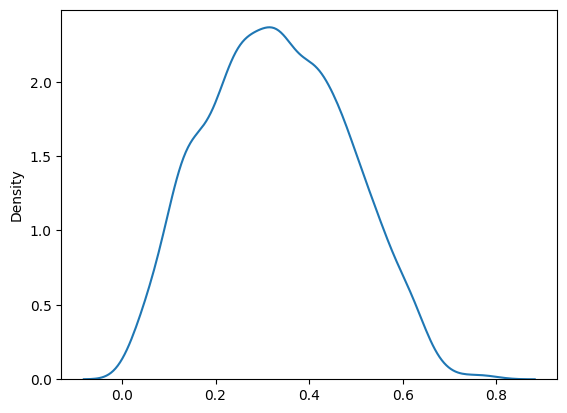

In [17]:
import seaborn as sns

sns.kdeplot([i.cpu().item() for i in results3])

In [21]:
top100 = np.array(sorted(scores.items(), key=lambda x: x[1]['group_density'], reverse=True))[0:200]#[[36, 29, 43, 82]]

for key, vals in top100:
    frame_pos=points[vals['nn_idx']].mean(axis=0)
    # print(vals['group_density'])
    print("draw sphere {",frame_pos.numpy()[0],frame_pos.numpy()[1],frame_pos.numpy()[2],"} radius 1")

draw sphere { -4.6 10.55 8.15 } radius 1
draw sphere { 9.35 10.85 11.0 } radius 1
draw sphere { -4.75 10.55 8.6 } radius 1
draw sphere { 10.1 10.85 11.0 } radius 1
draw sphere { 10.1 10.85 10.25 } radius 1
draw sphere { 10.1 10.1 11.0 } radius 1
draw sphere { -4.3 10.55 7.25 } radius 1
draw sphere { 9.35 10.1 11.0 } radius 1
draw sphere { 9.35 10.85 10.25 } radius 1
draw sphere { 9.5 10.7 11.6 } radius 1
draw sphere { 1.25 -6.25 -18.25 } radius 1
draw sphere { 9.35 10.25 11.6 } radius 1
draw sphere { 1.1 -7.0 -18.1 } radius 1
draw sphere { 10.1 10.25 11.6 } radius 1
draw sphere { 1.7 -6.4 -18.25 } radius 1
draw sphere { 16.1 -8.65 6.5 } radius 1
draw sphere { 9.5 11.3 10.1 } radius 1
draw sphere { 10.25 10.85 11.6 } radius 1
draw sphere { 10.1 10.1 10.25 } radius 1
draw sphere { -3.25 -11.65 -3.55 } radius 1
draw sphere { -3.25 -11.65 -3.55 } radius 1
draw sphere { -3.25 -11.65 -3.55 } radius 1
draw sphere { 15.65 -8.65 6.5 } radius 1
draw sphere { 8.0 6.2 13.4 } radius 1
draw sphere {

In [14]:
import numpy as np
import torch


def get_points(
    start,
    translated,          # [N_atoms, 3]
    frame_pos,           # [3]
    space=0.65,
    bottom_threshold=2.5,
    top_threshold=3.5,
    min_radius=12.,
    max_radius=25.,
    distance_to=20.0,
    chunk_size=2048,
):
    """
    Generate grid points, exclude points too close to atoms,
    and keep points near frame_pos.

    Memory safe: no full distance matrix.
    """

    device = translated.device

    # ---------------------------------------------------------
    # 1. Grid extent selection
    # ---------------------------------------------------------
    if distance_to <= 7.5:
        extent = 11
    elif distance_to <= 9:
        extent = 13
    elif distance_to <= 12:
        extent = 16
    else:
        extent = 25

    edges = np.arange(-extent, extent + space, space)

    # ---------------------------------------------------------
    # 2. Generate spherical shell grid
    # ---------------------------------------------------------
    pts = []
    rmin2 = 3.5 ** 2
    rmax2 = extent ** 2

    for x in edges:
        x2 = x * x
        for y in edges:
            xy2 = x2 + y * y
            if xy2 > rmax2:
                continue
            for z in edges:
                r2 = xy2 + z * z
                if rmin2 <= r2 <= rmax2:
                    pts.append((x, y, z))

    points_3d = torch.tensor(pts, dtype=torch.float32, device=device)

    # ---------------------------------------------------------
    # 3. Cull atoms that can never affect kept points
    # ---------------------------------------------------------
    # Worst-case geometry bound
    print(torch.norm(frame_pos), max(max_radius, distance_to), top_threshold)
    max_relevant = torch.norm(frame_pos) + max(max_radius, distance_to) + top_threshold

    atom_dist = torch.norm(translated, dim=1)
    atom_mask = atom_dist <= max_relevant
    exclude_points = translated[atom_mask]

    # ---------------------------------------------------------
    # 4. Distance-based exclusion (chunked)
    # ---------------------------------------------------------
    min_dist = torch.full(
        (points_3d.shape[0],),
        float("inf"),
        device=device
    )

    for i in range(0, exclude_points.shape[0], chunk_size):
        ep = exclude_points[i:i + chunk_size]
        d = torch.cdist(points_3d, ep)           # [P, chunk]
        min_dist = torch.minimum(min_dist, d.min(dim=1).values)

    # outside bottom_threshold AND inside top_threshold
    valid = (min_dist >= bottom_threshold) & (min_dist < top_threshold)
    filtered_points = points_3d[valid]

    # ---------------------------------------------------------
    # 5. Final restriction around frame_pos
    # ---------------------------------------------------------
    dist_to_frame = torch.norm(filtered_points - frame_pos, dim=1)

    
    filtered_points = filtered_points[(dist_to_frame <= max_radius) & (dist_to_frame >= min_radius)]

    return filtered_points


In [8]:
def build_complete_edge_index(N, device):
    idx = torch.arange(N, device=device)
    i, j = torch.meshgrid(idx, idx, indexing="ij")

    mask = i != j  # no self-loops
    edge_index = torch.stack([i[mask], j[mask]], dim=0)
    return edge_index

# DO THIS ONCE
global_bonds = []  # (a1, a2, order)

for bond in mol.GetBonds():
    a1 = bond.GetBeginAtomIdx()
    a2 = bond.GetEndAtomIdx()

    if a1 in gas_atoms or a2 in gas_atoms:
        continue

    bt = bond.GetBondType()
    order = (
        1 if bt == Chem.rdchem.BondType.SINGLE else
        2 if bt == Chem.rdchem.BondType.DOUBLE else
        3 if bt == Chem.rdchem.BondType.AROMATIC else
        1
    )

    global_bonds.append((a1, a2, order))
    global_bonds.append((a2, a1, order))

# gas bonds
for a1, a2 in gas_atoms:
    global_bonds.append((a1, a2, 1))

In [5]:
# types_array_atom.shape
def build_complete_edge_index(N, device):
    idx = torch.arange(N, device=device)
    i, j = torch.meshgrid(idx, idx, indexing="ij")

    mask = i != j  # no self-loops
    edge_index = torch.stack([i[mask], j[mask]], dim=0)
    return edge_index

# DO THIS ONCE
global_bonds = []  # (a1, a2, order)

for bond in mol.GetBonds():
    a1 = bond.GetBeginAtomIdx()
    a2 = bond.GetEndAtomIdx()

    if a1 in gas_atoms or a2 in gas_atoms:
        continue

    bt = bond.GetBondType()
    order = (
        1 if bt == Chem.rdchem.BondType.SINGLE else
        2 if bt == Chem.rdchem.BondType.DOUBLE else
        3 if bt == Chem.rdchem.BondType.AROMATIC else
        1
    )

    global_bonds.append((a1, a2, order))
    global_bonds.append((a2, a1, order))

# gas bonds
for a1, a2 in gas_atoms:
    global_bonds.append((a1, a2, 1))
    global_bonds.append((a2, a1, 1))


from torch_geometric.data import Data
def extract_point_cloud(atom_matrix, positions, center):
    """
    Formats the already-cropped atom features and positions into a Data object.
    """
    if positions.shape[0] == 0:
        return None  # Skip empty cubes

    # Center coordinates relative to cube center
    centered_positions = positions - center

    return Data(x=atom_matrix, pos=centered_positions)

path_dict = {
    'P1':'P1', 
    'P_main (PmR)':'PmR', 
    'P_main (mid)':'mid', 
    'P_reverse':'P_reverse', 
    'P_main (PmL)':'PmL',
       'P3':'P3'
}

def write_pdb2(inds, what, xs, ys, zs, chain='C', file="ml_out.pdb"):
    
    print(file)
    
    fpdb = open(file, 'wt')
    norm = torch.max(what[inds])
    i_atom = 1
    i_resid = 1
    for i, dind in enumerate(inds):

        fpdb.write('{:6s}{:5d} {:^4s}{:1s}{:3s} {:1s}{:4d}{:1s}   {:8.3f}{:8.3f}{:8.3f}{:6.2f}{:6.2f}          {:>2s}{:2s}\n'.format(
            'ATOM',i_atom,
            'GG','','GG',
            chain,i_resid,'',
            xs[dind],ys[dind],zs[dind],
            -1.0*torch.log10(what[dind]/norm),(what[dind]),
            'K',''))
        i_atom += 1
        if i_atom > 999:
            i_atom = 1
            i_resid += 1
            #eigv[dind,0],mm.pi[dind],
    fpdb.write('TER\n')
    fpdb.close()

def axis_without_center(minv, maxv, space, hole=3.5):
    left  = np.arange(minv, -hole, space)
    right = np.arange(hole, maxv + space, space)
    return np.concatenate([left, right])

import numpy as np
import torch


def get_points(
    start,
    translated,          # [N_atoms, 3]
    frame_pos,           # [3]
    space=0.65,
    bottom_threshold=2.5,
    top_threshold=3.5,
    radius=4.5,
    distance_to=20.0,
    chunk_size=2048,
):
    """
    Generate grid points, exclude points too close to atoms,
    and keep points near frame_pos.

    Memory safe: no full distance matrix.
    """

    device = translated.device

    # ---------------------------------------------------------
    # 1. Grid extent selection
    # ---------------------------------------------------------
    if distance_to <= 7.5:
        extent = 11
    elif distance_to <= 9:
        extent = 13
    elif distance_to <= 12:
        extent = 16
    else:
        extent = 20

    edges = np.arange(-extent, extent + space, space)

    # ---------------------------------------------------------
    # 2. Generate spherical shell grid
    # ---------------------------------------------------------
    pts = []
    rmin2 = 3.5 ** 2
    rmax2 = extent ** 2

    for x in edges:
        x2 = x * x
        for y in edges:
            xy2 = x2 + y * y
            if xy2 > rmax2:
                continue
            for z in edges:
                r2 = xy2 + z * z
                if rmin2 <= r2 <= rmax2:
                    pts.append((x, y, z))

    points_3d = torch.tensor(pts, dtype=torch.float32, device=device)

    # ---------------------------------------------------------
    # 3. Cull atoms that can never affect kept points
    # ---------------------------------------------------------
    # Worst-case geometry bound
    max_relevant = torch.norm(frame_pos) + max(radius, distance_to) + top_threshold

    atom_dist = torch.norm(translated, dim=1)
    atom_mask = atom_dist <= max_relevant
    exclude_points = translated[atom_mask]

    # ---------------------------------------------------------
    # 4. Distance-based exclusion (chunked)
    # ---------------------------------------------------------
    min_dist = torch.full(
        (points_3d.shape[0],),
        float("inf"),
        device=device
    )

    for i in range(0, exclude_points.shape[0], chunk_size):
        ep = exclude_points[i:i + chunk_size]
        d = torch.cdist(points_3d, ep)           # [P, chunk]
        min_dist = torch.minimum(min_dist, d.min(dim=1).values)

    # outside bottom_threshold AND inside top_threshold
    valid = (min_dist >= bottom_threshold) & (min_dist < top_threshold)
    filtered_points = points_3d[valid]

    # ---------------------------------------------------------
    # 5. Final restriction around frame_pos
    # ---------------------------------------------------------
    dist_to_frame = torch.norm(filtered_points - frame_pos, dim=1)

    
    filtered_points = filtered_points[dist_to_frame <= radius]

    return filtered_points



def get_fe_bias(
    xyz2,
    frame_pos,
    point=None,
    alpha=10.0,
    beta=1.0,
    denom=4,
    range_=0.75,
):
    """
    alpha → dominance of reference-point distance
    beta  → influence of closeness to the line
    point → reference point [3], defaults to origin
    """

    if point is None:
        point = torch.zeros(3, device=xyz2.device, dtype=xyz2.dtype)
    else:
        point = torch.as_tensor(point, device=xyz2.device, dtype=xyz2.dtype)

    # Shift coordinates so "point" becomes the origin
    xyz_rel = xyz2 - point  # [N, 3]

    # ------------------------------
    # Distance to reference point (dominant term)
    # ------------------------------
    dist_point = torch.norm(xyz_rel, dim=1)  # [N]
    origin_score = 1.0 / (dist_point**denom + 1e-8)

    # ------------------------------
    # Distance to line through `point`
    # ------------------------------
    line_dir = frame_pos / torch.norm(frame_pos)  # [3]
    t = (xyz_rel * line_dir).sum(dim=1, keepdim=True)
    d_perp = torch.norm(xyz_rel - t * line_dir, dim=1)

    line_score = 1.0 / (d_perp + 1e-8)

    # ------------------------------
    # Combine WITHOUT global normalization
    # ------------------------------
    combined = alpha * origin_score + beta * line_score

    # ------------------------------
    # Scale result to 0–range_ while preserving ranking
    # ------------------------------
    combined_min = combined.min()
    combined_max = combined.max()

    score = range_ * (combined - combined_min) / (combined_max - combined_min + 1e-8)

    return score


import torch
def get_best(density, pos_embedding, k=5):
# points: [N,3], density: [N]
    # k = 5
    points = torch.stack([p.center for p in pos_embedding])
    # density=density
    N = points.shape[0]

    best_sum = -1
    best_group = None
    best_ndx = None
    scores = {}

    for i in range(N):
        # compute distances from point i
        dists = torch.norm(points - points[i], dim=1)  # [N]
        
        # find indices of the closest k points including self
        _, nn_idx = torch.topk(-dists, k)  # negative because topk returns largest
        
        # sum densities in this group
        group_density = density[nn_idx].sum()
        scores[i] = {}
        scores[i]['group_density'] = group_density
        scores[i]['nn_idx'] = nn_idx
        
        if group_density > best_sum:
            best_sum = group_density
            best_group = nn_idx
            best_ndx = i

    highest_cluster_points = points[best_group]
    highest_cluster_density = density[best_group]

    return scores, points


def topk_with_radius(density, pos_embedding, k=5, radius=2.0, threshold=0.5):
    density = density.to('cpu')
    points = torch.stack([p.center for p in pos_embedding])
    keep = torch.where(density > threshold)[0]
    while len(keep) < (3*k):
        print(len(keep),threshold)
        threshold = threshold/2
        if np.isclose(0,threshold,.001):
            break
        keep = torch.where(density > threshold)[0]
        print(len(keep),threshold)
    points = points[keep]
    density = density[keep]
    print("Keeping:", density.shape, ", at score >=", threshold)
    N = points.shape[0]
    best_sum = -1
    best_group = None
    best_ndx = None
    scores = {}

    for i in range(N):
        # distances from point i
        dists = torch.norm(points - points[i], dim=1)

        # initial K nearest indices (including itself)
        _, nn_idx = torch.topk(-dists, k)

        # extract positions of candidate group
        group_pts = points[nn_idx]            # [k,3]

        # compute pairwise distance matrix within group
        pdist = torch.norm(
            group_pts.unsqueeze(1) - group_pts.unsqueeze(0),
            dim=2
        )  # [k, k]
        # check radius requirement: all pairwise distances ≤ radius
        if (pdist <= radius).all():
            group_density = density[nn_idx].sum()

            if group_density > best_sum:
                best_sum = group_density
                best_group = nn_idx
                best_ndx = i
            scores[i] = {}
            scores[i]['group_density'] = group_density
            scores[i]['nn_idx'] = nn_idx

    return scores, points

# Map from global RDKit atom idx → local 0..N-1
import itertools

def build_edges_and_attrs_fast(inside_indices, edge_index_cache):
    device = inside_indices.device
    N = inside_indices.shape[0]

    # global → local
    atom_to_local = {int(a): i for i, a in enumerate(inside_indices.tolist())}

    # edge_index is reused
    edge_index = edge_index_cache

    # initialize all nonbonded = 0
    edge_attr = torch.zeros(
        (edge_index.shape[1], 1),
        dtype=torch.long,
        device=device
    )

    # overwrite bonded edges only
    # map (i,j) → edge position once
    edge_pos = {
        (int(i), int(j)): k
        for k, (i, j) in enumerate(edge_index.t().tolist())
    }

    for a1, a2, order in global_bonds:
        if a1 in atom_to_local and a2 in atom_to_local:
            i = atom_to_local[a1]
            j = atom_to_local[a2]
            edge_attr[edge_pos[(i, j)], 0] = order

    return edge_index, edge_attr



def embed(xyz2, step, protein_coords_list,protein_cofactors,global_to_local, radius=5, frame_emb=None):
    print("STEP:", step)
    # xyz2:  grid point coordinates for the frame we are trying to predictt, i.e. the next frame, 
    # frame_pos: the given O2 in frame 0
    # first frame frame_pos for O2 is given, each one after is prediction from one before
    # 0 is first step which is given and we start to predict from 1

    pos_embedding = []
    xyz = []
    atom_coords = protein_coords_list
    
    # print(dist)
    min_dist = 2.5
    
    for i, point in enumerate(xyz2[0:]):
        center = point
        dist = torch.norm(center - atom_coords[cat[0],:])
      
      
        # radius = 6.0

        # Compute distances of all atoms to perturbed point
        dists = torch.norm(atom_coords - center, dim=1)

        # Indices of atoms inside sphere
                    # Indices of atoms inside sphere
        inside_indices = protein_cofactors[torch.where(dists <= radius)[0]]

        # Ensure inside_indices is always a 1D tensor
        if torch.is_tensor(inside_indices) and inside_indices.ndim == 0:
            inside_indices = inside_indices.unsqueeze(0)

        if isinstance(inside_indices, (int, np.integer)):
            inside_indices = torch.tensor([inside_indices], device=device)

        if inside_indices.numel() == 0:
            dddd = torch.cdist(center.unsqueeze(0), atom_coords)
            print('too far start or end', dddd.min(), flush=True)
            continue
        xyz.append(i)
        local_inside_indices = np.array([global_to_local[int(g)] for g in inside_indices])

        atom_matrix=types_array_atom[inside_indices]
        positions=atom_coords[local_inside_indices]
        node_directions = positions - atom_coords[cat[0],:]
        node_distances = torch.norm(node_directions, dim=1)
        local_pos_normalized = (positions - center)/radius  # shape [N, 3]
        
        # atom_matrix_arr.append(atom_matrix)
        # positions_arr.append(positions)
        test = extract_point_cloud(atom_matrix, positions, center)
        # test.x=torch.column_stack([test.x, torch.tensor(frame_emb[idx]).repeat(len(test.x))])
        if frame_emb is not None:
            frame_vector = frame_emb[step]          # [16]
            frame_vector = frame_vector.unsqueeze(0)           # [1, 16]
            frame_vector = frame_vector.expand(len(test.x), -1)  # [N, 16]
            test.distance = dist.expand(len(test.x))
            test.x = torch.cat([test.x, frame_vector], dim=1)    # [N, 6 + 16]

        # print("bulding edges for point:", i+1)
        N=len(inside_indices)
        edge_index_cache = build_complete_edge_index(N, 'cpu')
        # test.edge_index, test.edge_attr = build_edges_and_attrs(inside_indices)
        test.edge_index, test.edge_attr = build_edges_and_attrs_fast(inside_indices, edge_index_cache)
        # print("\tdone bulding edges for point:", i+1)
        test.inside_indices = inside_indices
        test.local_inside_indices = local_inside_indices
        test.center = center
        test.node_attr = local_pos_normalized
        test.node_directions = node_directions
        test.node_distances = node_distances
        pos_embedding.append(test)
    # print("DOEN")
    xyz2 = xyz2[xyz]
    return xyz2, pos_embedding

import torch
import math

def predict(pos_embedding, model, bs=5, frame_emb_bool=False, node_input_bool=False, atom_as_node_attr=False):
    # model = torch.load('../Sim1/model.pt') # 
    # model=torch.load("../Sim5/model%d_FE2dis_inr6.pt"%24)
    model=torch.load(model)
    device='cuda'
    model = model.to(device)


    test_loader = DataLoader(pos_embedding, batch_size=bs, shuffle=False) 


    values = []
    with torch.no_grad():
        for batch_idx, (data_list) in enumerate(test_loader):
            torch.cuda.empty_cache()
            if (batch_idx + 1) % 50 == 0:
                print("Batch",batch_idx+1, flush=True)
            if isinstance(data_list, list):
                from torch_geometric.data import Batch
                batch = Batch.from_data_list(data_list)
            else:
                batch = data_list  # if batch_size=1, it might already be a Data object

            batch = batch.to('cuda')
            

            
            distance = torch.norm(batch.node_attr[:, :3], dim=1, keepdim=True)  # [N, 1]

            # 2. Convert Cartesian vectors to irreps vector
            x = CartesianTensor("i")
            vector_irrep = x.from_cartesian(batch.node_attr[:, :3])  # [N, 3]

          
            atom_type_onehot = batch.x[:, 0:9]
            
            frame_emb = batch.x[:, 9:] 
            if frame_emb_bool:
                if atom_as_node_attr:
                    node_attr = torch.cat([
                        distance,            # 1 scalar (0e)
                        atom_type_onehot,    # 6 scalars (0e)
                        frame_emb,           # k scalars (0e)
                        vector_irrep,        # 3-vector (1o)
                    ], dim=1)
                else:
                    node_attr = torch.cat([
                        distance,            # 1 scalar (0e)
                        # atom_type_onehot,    # 6 scalars (0e)
                        frame_emb,           # k scalars (0e)
                        vector_irrep,        # 3-vector (1o)
                    ], dim=1)

            else:
                # node_attr = torch.cat([distance, vector_irrep, frame_emb], dim=1)
                if atom_as_node_attr:
                    node_attr = torch.cat([
                        distance,            # 1 scalar (0e)
                        atom_type_onehot,    # 6 scalars (0e)
                        # frame_emb,           # k scalars (0e)
                        vector_irrep,        # 3-vector (1o)
                    ], dim=1)
                else:
                    node_attr = torch.cat([
                        distance,            # 1 scalar (0e)
                        # atom_type_onehot,    # 6 scalars (0e)
                        # frame_emb,           # k scalars (0e)
                        vector_irrep,        # 3-vector (1o)
                    ], dim=1)

            
            # node_input = torch.ones((batch.num_nodes, 1), device=batch.x.device)
            if node_input_bool:
                node_input = torch.cat([
                    # batch.distance.unsqueeze(-1), # 1 scalar (0e) distance of center of graph to iron
                    batch.node_distances.unsqueeze(-1),    # 1 scalar (0e) distance to iron for each atom
                    F.normalize(batch.node_directions, p=2, dim=1),        # 3-vector (1o) direction to iron for each atom
                ], dim=1)
            else:
                node_input = torch.ones((batch.num_nodes, 1), device=batch.x.device)

            if not atom_as_node_attr:
                data = {
                "batch": batch.batch,
                # "x": batch.x[:,0:6], # atom type
                # "frame_emb": frame,
                "x": atom_type_onehot,
                "node_attr": node_attr, 
                "edge_index": batch.edge_index,
                "edge_attr": batch.edge_attr,
                "pos": batch.pos,  # if needed in preprocess
            }
            else:
                data = {
                    "batch": batch.batch,
                    # "x": batch.x[:,0:6], # atom type
                    # "frame_emb": frame,
                    "x": node_input,
                    "node_attr": node_attr, 
                    "edge_index": batch.edge_index,
                    "edge_attr": batch.edge_attr,
                    "pos": batch.pos,  # if needed in preprocess
                }

            outputs = model(data)
            preds = torch.sigmoid(outputs.squeeze(-1))
            values.append(preds)
            torch.cuda.empty_cache()

        results = torch.concat(values)
        best = results.argmax() # 2552
        best_pos = best#xyz2[best]
        return best, best_pos, results

def sinusoidal_embedding(frame_idx: torch.Tensor, dim: int = 16):
    """
    frame_idx: tensor of shape [N] with normalized frame values in [0,1]
    dim: embedding dimension (should be even)
    Returns: tensor of shape [N, dim]
    """
    device = frame_idx.device
    N = frame_idx.size(0)
    pe = torch.zeros(N, dim, device=device)

    position = frame_idx.unsqueeze(1)  # [N, 1]
    div_term = torch.exp(torch.arange(0, dim, 2, device=device) * -(math.log(10000.0) / dim))  # [dim/2]

    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe  # [N, dim]

In [ ]:
set fit_0 [atomselect 45 "noh and protein" frame 0]
set fit [atomselect 31 "noh and protein" frame 84]
measure fit $fit $fit_0

In [37]:
import numpy as np

new_start = np.array([0,0,0])  # center of new molecule usually metal
original_start = np.array([0,0,0]) # original origin metal

# vmd_draw_arrow top {0 0 0} {-25.166172698677443 -7.6472436256614245 -3.243971393618015} # p2
# vmd_draw_arrow top {0 0 0} {-25.754505989546175 2.6306397223212414 3.124768676911888} # p_main
# vmd_draw_arrow top {0 0 0} {-13.946051630007261 -21.11993741769362 -8.115977662367786} # p1
# vmd_draw_arrow top {0 0 0} {-8.817937229724599 17.392401505194584 -14.780387575226339} # p3
# vmd_draw_arrow top {0 0 0} {-11.35593020970385 1.2394844905900513 -22.635072989837973} # p4
# vmd_draw_arrow top {0 0 0} {23.042901039830326 -4.4894851173109345 -4.873893933629606} # p_r



p_start = original_start
p_end=np.array([-25.754505989546175, 2.6306397223212414, 3.124768676911888]) # P_main
# p_end=np.array([-13.946051630007261, -21.11993741769362, -8.115977662367786]) # P1
# p_end=np.array([-25.166172698677443, -7.6472436256614245, -3.243971393618015]) # P2
# p_end=np.array([-8.817937229724599, 17.392401505194584, -14.780387575226339]) # P3
# p_end=np.array([23.042901039830326, -4.4894851173109345, -4.873893933629606]) # P_reverse
# p_end=np.array([-11.35593020970385, 1.2394844905900513, -22.635072989837973]) # P4



#O2QD roto matrix
# Define 4x4 roto-translation matrix

# MSM roto matrix
M = np.array([
    [0.445575088262558, 0.536340057849884, -0.7167999148368835, -0.02650165557861328],
    [0.13352538645267487, 0.7519046068191528, 0.6456085443496704, -0.06863164901733398],
    [0.8852309584617615, -0.3833780884742737, 0.2634149491786957, 0.29916083812713623],
    [0.0, 0.0, 0.0, 1.0]
])

# Convert to homogeneous coordinates (add 1 for matrix multiplication)
p_start_hom = np.append(p_start, 1)  # [x, y, z, 1]
p_end_hom = np.append(p_end, 1)  # [x, y, z, 1]

# Apply the roto-translation
p_start_transformed = M @ p_start_hom
p_end_transformed = M @ p_end_hom

# Extract only the (x, y, z) components
p_start_transformed = p_start_transformed[:3]
p_end_transformed = p_end_transformed[:3]

# Shift the transformed vector to start at (0,0,0)
p_vector_transformed = p_end_transformed - p_start_transformed


# Shift the transformed vector to start at (0,0,0)
p_vector_transformed = p_end_transformed - p_start_transformed

print("New Start Point (should be 0,0,0):", np.array([0,0,0]))
print("New End Point:", p_vector_transformed)
# p_vector_transformed2  = p_vector_transformed + np.array([19.817844,4.080989,-15.953906]) 
# print("vmd_draw_arrow 6 {19.817844 4.080989 -15.953906} {" + str(p_vector_transformed2[0]) + ' ' + str(p_vector_transformed2[1]) + ' ' + str(p_vector_transformed2[2]) + '}')
p_vector_transformed2  = p_vector_transformed + new_start
print("vmd_draw_arrow top {0 0 0} {" + str(p_vector_transformed2[0]) + ' ' + str(p_vector_transformed2[1]) + ' ' + str(p_vector_transformed2[2]) + '}')

New Start Point (should be 0,0,0): [0 0 0]
New End Point: [-12.30448274   0.55648712 -22.98410487]
vmd_draw_arrow top {0 0 0} {-12.304482740094041 0.5564871178734452 -22.984104867819227}


In [ ]:
vmd_draw_arrow top {0 0 0} {-12.989664291344706 -11.204656296074585 -20.200600095348328} # p2
vmd_draw_arrow top {0 0 0} {-12.304482740094041 0.5564871178734452 -22.984104867819227} # p_main
vmd_draw_arrow top {0 0 0} {-11.723949545143125 -22.982074698057417 -6.386425258764913} # p1
vmd_draw_arrow top {0 0 0} {15.993769025194611 2.3576638317239382 -18.367151710533008} # p3
vmd_draw_arrow top {0 0 0} {11.829683969337363 -15.197727395442598 -16.490228779731172} # p4
vmd_draw_arrow top {0 0 0} {11.353058713662751 -3.445479843423328 20.83560307290749} # p_r


vmd_draw_arrow_s top {0 0 0} {-12.989664291344706 -11.204656296074585 -20.200600095348328}
vmd_draw_arrow_s top {0 0 0} {-12.304482740094041 0.5564871178734452 -22.984104867819227}
vmd_draw_arrow_s top {0 0 0} {-11.723949545143125 -22.982074698057417 -6.386425258764913}
vmd_draw_arrow_s top {0 0 0} {15.993769025194611 2.3576638317239382 -18.367151710533008}
vmd_draw_arrow_s top {0 0 0} {11.829683969337363 -15.197727395442598 -16.490228779731172}
vmd_draw_arrow_s top {0 0 0} {11.353058713662751 -3.445479843423328 20.83560307290749}

In [ ]:
top10 = np.array(sorted(scores.items(), key=lambda x: x[1]['group_density'], reverse=True))[[35, 28, 42, 81]]

for key, vals in top10:
    frame_pos=points[vals['nn_idx']].mean(axis=0)
    # print(key, vals['group_density'], points[vals['nn_idx']].mean(axis=0))
    print("draw sphere {",frame_pos.numpy()[0],frame_pos.numpy()[1],frame_pos.numpy()[2],"} radius 1")

draw sphere { 10.48 -6.2 -4.32 } radius 1
draw sphere { -3.6 -4.24 -18.16 } radius 1
draw sphere { 4.28 -13.36 -7.36 } radius 1
draw sphere { 4.52 -6.64 -12.72 } radius 1
